# 01. Сбор и обработка данных

Этот ноутбук загружает сырые CSV-файлы, очищает данные, агрегирует их до недельной частоты и сохраняет итоговый датасет `data/processed/merged_weekly.csv`.

**Переменные на выходе:**
- `r_btc` — недельная логарифмическая доходность BTC
- `r_btc_lag` — лаговая доходность BTC (t−1), прокси для momentum
- `volume_btc` — логарифм недельного объёма торгов BTC
- `google_trends` — индекс Google Trends по запросу «Bitcoin» (нормирован к 100)
- `r_sp500` — недельная логарифмическая доходность S&P 500
- `vix` — среднее значение индекса VIX за неделю
- `dxy` — недельная логарифмическая доходность индекса DXY

**Период анализа:** 2017-01-01 — 2025-03-01  
**Подпериоды:** 2017–2019 (менее зрелый рынок) и 2020–2025 (более зрелый рынок)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Пути к файлам
RAW_DIR = '../data/raw/'
PROCESSED_DIR = '../data/processed/'

print('Библиотеки загружены.')

Matplotlib is building the font cache; this may take a moment.


Библиотеки загружены.


## 1. Вспомогательные функции

In [4]:
def parse_investing_csv(filepath, price_col='Price'):
    """
    Загружает CSV-файл с Investing.com.
    Обрабатывает: BOM, запятые в числах, суффиксы K/M/B в объёме.
    Возвращает DataFrame с DatetimeIndex, отсортированный по возрастанию.
    """
    df = pd.read_csv(filepath, encoding='utf-8-sig')
    df.columns = df.columns.str.strip()
    
    # Парсим дату
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    df = df.set_index('Date').sort_index()
    
    # Конвертируем числовые столбцы (убираем запятые)
    for col in ['Price', 'Open', 'High', 'Low']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(',', '', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Конвертируем объём (K → тысячи, M → миллионы, B → миллиарды)
    if 'Vol.' in df.columns:
        vol = df['Vol.'].astype(str).str.strip()
        multipliers = vol.str[-1].map({'K': 1e3, 'M': 1e6, 'B': 1e9})
        numeric_vol = pd.to_numeric(vol.str[:-1], errors='coerce')
        has_suffix = vol.str[-1].isin(['K', 'M', 'B'])
        df['Volume'] = np.where(has_suffix, numeric_vol * multipliers, pd.to_numeric(vol, errors='coerce'))
        df = df.drop(columns=['Vol.'])
    
    # Убираем Change %
    if 'Change %' in df.columns:
        df = df.drop(columns=['Change %'])
    
    return df


def log_return(series):
    """Логарифмическая доходность."""
    return np.log(series / series.shift(1))


print('Функции определены.')

Функции определены.


## 2. Загрузка и очистка данных

### 2.1 Bitcoin (BTC/USD)

In [5]:
btc = parse_investing_csv(RAW_DIR + 'btc_price.csv')
btc = btc[['Price', 'Volume']].rename(columns={'Price': 'btc_close', 'Volume': 'btc_volume'})

print(f'BTC: {btc.index.min().date()} — {btc.index.max().date()}, строк: {len(btc)}')
print(f'Пропуски: {btc.isnull().sum().to_dict()}')
btc.tail(3)

BTC: 2017-01-09 — 2025-03-01, строк: 2974
Пропуски: {'btc_close': 0, 'btc_volume': 0}


,btc_close,btc_volume
Date,,
2025-02-27,84714.6,116140.0
2025-02-28,84381.2,186900.0
2025-03-01,86071.6,79510.0


### 2.2 S&P 500

In [6]:
sp500 = parse_investing_csv(RAW_DIR + 'sp500.csv')
sp500 = sp500[['Price']].rename(columns={'Price': 'sp500_close'})

print(f'S&P 500: {sp500.index.min().date()} — {sp500.index.max().date()}, строк: {len(sp500)}')
print(f'Пропуски: {sp500.isnull().sum().to_dict()}')
sp500.tail(3)

S&P 500: 2017-01-03 — 2025-02-28, строк: 2051
Пропуски: {'sp500_close': 0}


,sp500_close
Date,
2025-02-26,5956.06
2025-02-27,5861.57
2025-02-28,5954.50


### 2.3 VIX

In [7]:
vix = parse_investing_csv(RAW_DIR + 'vix.csv')
vix = vix[['Price']].rename(columns={'Price': 'vix_close'})

print(f'VIX: {vix.index.min().date()} — {vix.index.max().date()}, строк: {len(vix)}')
print(f'Пропуски: {vix.isnull().sum().to_dict()}')
vix.tail(3)

VIX: 2017-01-03 — 2025-02-28, строк: 2054
Пропуски: {'vix_close': 0}


,vix_close
Date,
2025-02-26,20504.713
2025-02-27,21107.287
2025-02-28,20758.850


### 2.4 DXY (US Dollar Index)

In [8]:
dxy = parse_investing_csv(RAW_DIR + 'dxy.csv')
dxy = dxy[['Price']].rename(columns={'Price': 'dxy_close'})

print(f'DXY: {dxy.index.min().date()} — {dxy.index.max().date()}, строк: {len(dxy)}')
print(f'Пропуски: {dxy.isnull().sum().to_dict()}')
dxy.tail(3)

DXY: 2017-01-02 — 2025-02-28, строк: 2123
Пропуски: {'dxy_close': 0}


,dxy_close
Date,
2025-02-26,106.42
2025-02-27,107.24
2025-02-28,107.61


### 2.5 Google Trends

In [10]:
import os

# Определяем, один файл или директория
gt_path = RAW_DIR + 'google_trends.csv'
gt_dir = RAW_DIR

if os.path.isfile(gt_path):
    # Один сводный файл
    gt = pd.read_csv(gt_path)
    gt.columns = ['date', 'google_trends']
    gt['date'] = pd.to_datetime(gt['date'])
    gt = gt.set_index('date').sort_index()
    gt['google_trends'] = pd.to_numeric(gt['google_trends'], errors='coerce')
    print('Загружен один сводный файл Google Trends.')
elif os.path.isdir(gt_dir):
    # Несколько файлов в директории — конкатенируем
    files = sorted([f for f in os.listdir(gt_dir) if f.endswith('.csv')])
    dfs = []
    for f in files:
        tmp = pd.read_csv(gt_dir + f)
        tmp.columns = ['date', 'google_trends']
        tmp['date'] = pd.to_datetime(tmp['date'])
        tmp['google_trends'] = pd.to_numeric(tmp['google_trends'], errors='coerce')
        dfs.append(tmp)
    gt = pd.concat(dfs).drop_duplicates('date').sort_values('date').set_index('date')
    print(f'Загружено {len(files)} файлов Google Trends, объединены.')
else:
    raise FileNotFoundError('Файл(ы) Google Trends не найдены. Проверьте пути.')

print(f'Google Trends: {gt.index.min().date()} — {gt.index.max().date()}, строк: {len(gt)}')
print(f'Пропуски: {gt.isnull().sum().to_dict()}')
gt.tail(3)

Загружен один сводный файл Google Trends.
Google Trends: 2016-12-25 — 2025-03-02, строк: 428
Пропуски: {'google_trends': 0}


,google_trends
date,
2025-02-16,40
2025-02-23,65
2025-03-02,66


## 3. Агрегация до недельной частоты

Используем `resample('W-SUN')` — неделя заканчивается воскресеньем, чтобы совпадать с форматом Google Trends.

- **Цены (BTC, S&P 500, DXY):** последнее наблюдение недели (`last`)
- **Объём BTC:** сумма за неделю (`sum`)
- **VIX:** среднее за неделю (`mean`) — используется как уровень волатильности

In [11]:
# Агрегация
btc_w = btc.resample('W-SUN').agg({'btc_close': 'last', 'btc_volume': 'sum'})
sp500_w = sp500.resample('W-SUN').agg({'sp500_close': 'last'})
vix_w = vix.resample('W-SUN').agg({'vix_close': 'mean'})
dxy_w = dxy.resample('W-SUN').agg({'dxy_close': 'last'})

# Для S&P 500 и VIX: в выходные нет торгов → forward fill (максимум 5 дней)
sp500_w['sp500_close'] = sp500_w['sp500_close'].ffill(limit=1)
vix_w['vix_close'] = vix_w['vix_close'].ffill(limit=1)
dxy_w['dxy_close'] = dxy_w['dxy_close'].ffill(limit=1)

print(f'BTC недельный: {len(btc_w)} наблюдений')
print(f'S&P 500 недельный: {len(sp500_w)} наблюдений')
print(f'VIX недельный: {len(vix_w)} наблюдений')
print(f'DXY недельный: {len(dxy_w)} наблюдений')
print(f'Google Trends: {len(gt)} наблюдений')

BTC недельный: 425 наблюдений
S&P 500 недельный: 426 наблюдений
VIX недельный: 426 наблюдений
DXY недельный: 426 наблюдений
Google Trends: 428 наблюдений


## 4. Расчёт переменных

In [13]:
# Логарифмические доходности
btc_w['r_btc'] = log_return(btc_w['btc_close'])
sp500_w['r_sp500'] = log_return(sp500_w['sp500_close'])
dxy_w['r_dxy'] = log_return(dxy_w['dxy_close'])

# Логарифм объёма BTC (исключаем нули перед логарифмированием)
btc_w['log_volume_btc'] = np.log(btc_w['btc_volume'].replace(0, np.nan))

# VIX — используем уровень (не доходность)
vix_w = vix_w.rename(columns={'vix_close': 'vix'})

print('Переменные рассчитаны.')

Переменные рассчитаны.


## 5. Объединение датасета

In [14]:
# Собираем нужные столбцы
btc_vars = btc_w[['r_btc', 'log_volume_btc']]
sp500_vars = sp500_w[['r_sp500']]
vix_vars = vix_w[['vix']]
dxy_vars = dxy_w[['r_dxy']]
gt_vars = gt[['google_trends']]

# Объединяем по индексу (inner join — только недели, где есть все данные)
df = btc_vars.join([sp500_vars, vix_vars, dxy_vars], how='left')

# Google Trends: ближайшее совпадение (merge_asof по дате)
df = df.reset_index().rename(columns={'Date': 'date'})
gt_reset = gt_vars.reset_index().rename(columns={'date': 'date'})
df = pd.merge_asof(
    df.sort_values('date'),
    gt_reset.sort_values('date'),
    on='date',
    direction='nearest',
    tolerance=pd.Timedelta('3 days')
)
df = df.set_index('date')

# Лаг доходности BTC (momentum)
df['r_btc_lag'] = df['r_btc'].shift(1)

# Ограничиваем период анализа
df = df.loc['2017-01-01':'2025-03-01']

# Убираем строки с пропусками в ключевых переменных
key_vars = ['r_btc', 'r_btc_lag', 'log_volume_btc', 'google_trends', 'r_sp500', 'vix', 'r_dxy']
df_clean = df[key_vars].dropna()

print(f'Итоговый датасет: {len(df_clean)} наблюдений')
print(f'Период: {df_clean.index.min().date()} — {df_clean.index.max().date()}')
print(f'\nПропуски после очистки:')
print(df_clean.isnull().sum())

Итоговый датасет: 422 наблюдений
Период: 2017-01-29 — 2025-02-23

Пропуски после очистки:
r_btc             0
r_btc_lag         0
log_volume_btc    0
google_trends     0
r_sp500           0
vix               0
r_dxy             0
dtype: int64


In [15]:
df_clean.head(5)

,r_btc,r_btc_lag,log_volume_btc,google_trends,r_sp500,vix,r_dxy
date,,,,,,,
2017-01-29,-0.004691,0.112302,12.299745,4,0.010250,18.022,-0.002087
2017-02-05,0.105350,-0.004691,12.618182,4,0.001176,17.820,-0.006587
2017-02-12,-0.019478,0.105350,12.870486,4,0.008107,17.748,0.009269
2017-02-19,0.051248,-0.019478,12.314523,5,0.015041,16.682,0.001487
2017-02-26,0.110628,0.051248,12.864913,6,0.006824,17.235,0.001386


## 6. Быстрая визуальная проверка

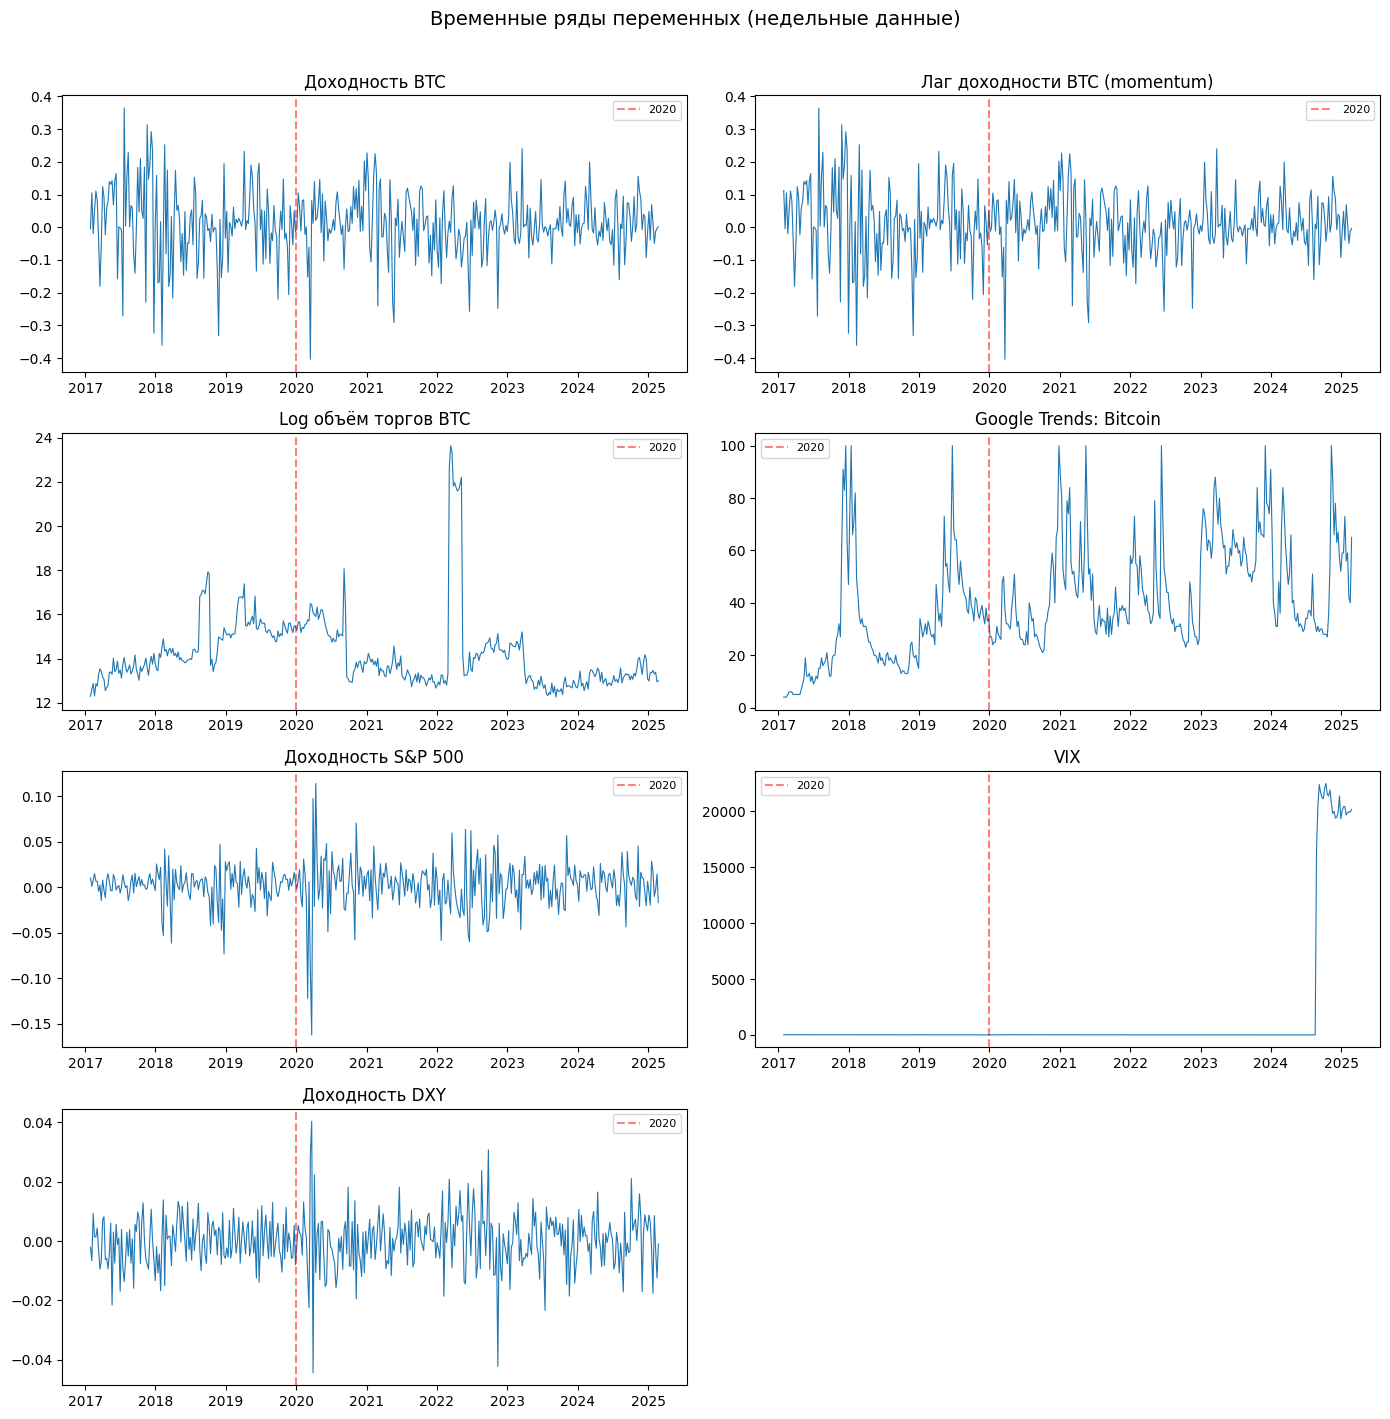

График сохранён: data/processed/timeseries_check.png


In [16]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle('Временные ряды переменных (недельные данные)', fontsize=14, y=1.01)

vars_titles = [
    ('r_btc', 'Доходность BTC'),
    ('r_btc_lag', 'Лаг доходности BTC (momentum)'),
    ('log_volume_btc', 'Log объём торгов BTC'),
    ('google_trends', 'Google Trends: Bitcoin'),
    ('r_sp500', 'Доходность S&P 500'),
    ('vix', 'VIX'),
    ('r_dxy', 'Доходность DXY'),
]

axes_flat = axes.flatten()
for i, (var, title) in enumerate(vars_titles):
    axes_flat[i].plot(df_clean.index, df_clean[var], linewidth=0.8)
    axes_flat[i].set_title(title)
    axes_flat[i].axvline(pd.Timestamp('2020-01-01'), color='red', linestyle='--', alpha=0.5, label='2020')
    axes_flat[i].legend(fontsize=8)

# Убираем лишний subplot
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('../data/processed/timeseries_check.png', dpi=100, bbox_inches='tight')
plt.show()
print('График сохранён: data/processed/timeseries_check.png')

## 7. Сохранение итогового датасета

In [17]:
import os
os.makedirs(PROCESSED_DIR, exist_ok=True)

df_clean.to_csv(PROCESSED_DIR + 'merged_weekly.csv')
print(f'Сохранено: {PROCESSED_DIR}merged_weekly.csv')
print(f'Размер датасета: {df_clean.shape}')
print(f'\nИтоговые переменные:')
print(df_clean.describe().round(4))

Сохранено: ../data/processed/merged_weekly.csv
Размер датасета: (422, 7)

Итоговые переменные:
          r_btc  r_btc_lag  log_volume_btc  google_trends   r_sp500  \
count  422.0000   422.0000        422.0000       422.0000  422.0000   
mean     0.0110     0.0113         14.2320        40.8673    0.0023   
std      0.1013     0.1014          1.6890        20.9306    0.0246   
min     -0.4036    -0.4036         12.2604         4.0000   -0.1623   
25%     -0.0286    -0.0286         13.1803        27.0000   -0.0092   
50%      0.0079     0.0082         13.8253        36.0000    0.0048   
75%      0.0657     0.0663         14.9423        54.0000    0.0152   
max      0.3648     0.3648         23.6334       100.0000    0.1142   

              vix     r_dxy  
count    422.0000  422.0000  
mean    1318.6757    0.0001  
std     5026.9397    0.0090  
min        2.1290   -0.0443  
25%        6.2446   -0.0054  
50%        8.0498    0.0008  
75%       11.0415    0.0058  
max    22479.9844    0.04

## 8. Разметка подпериодов

In [18]:
period1 = df_clean.loc['2017-01-01':'2019-12-31']
period2 = df_clean.loc['2020-01-01':'2025-03-01']

print(f'Подпериод 1 (2017–2019): {len(period1)} недель')
print(f'  {period1.index.min().date()} — {period1.index.max().date()}')
print(f'Подпериод 2 (2020–2025): {len(period2)} недель')
print(f'  {period2.index.min().date()} — {period2.index.max().date()}')

Подпериод 1 (2017–2019): 153 недель
  2017-01-29 — 2019-12-29
Подпериод 2 (2020–2025): 269 недель
  2020-01-05 — 2025-02-23
